# Part B : News Article Classification

# Task 1: Data Collection and Preprocessing

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
# Load Dataset
df = pd.read_csv("data_news.csv")  # Change filename as needed
# Show column names
print("Available columns:", df.columns.tolist())
df.head()


Available columns: ['category', 'headline', 'links', 'short_description', 'keywords']


,category,headline,links,short_description,keywords
0,WELLNESS,143 Miles in 35 Days: Lessons Learned,https://www.huffingtonpost.com/entry/running-l...,Resting is part of training. I've confirmed wh...,running-lessons
1,WELLNESS,Talking to Yourself: Crazy or Crazy Helpful?,https://www.huffingtonpost.com/entry/talking-t...,Think of talking to yourself as a tool to coac...,talking-to-yourself-crazy
2,WELLNESS,Crenezumab: Trial Will Gauge Whether Alzheimer...,https://www.huffingtonpost.com/entry/crenezuma...,The clock is ticking for the United States to ...,crenezumab-alzheimers-disease-drug
3,WELLNESS,"Oh, What a Difference She Made",https://www.huffingtonpost.com/entry/meaningfu...,"If you want to be busy, keep trying to be perf...",meaningful-life
4,WELLNESS,Green Superfoods,https://www.huffingtonpost.com/entry/green-sup...,"First, the bad news: Soda bread, corned beef a...",green-superfoods


In [3]:
# Check shape of the dataset
print("Dataset shape:", df.shape)

# Check if any missing values are present
print("\nMissing values:\n", df.isnull().sum())

# Check the distribution of categories
print("\nCategory distribution:\n", df['category'].value_counts())


Dataset shape: (50000, 5)

Missing values:
 category                0
headline                0
links                   0
short_description       0
keywords             2668
dtype: int64

Category distribution:
 category
WELLNESS          5000
POLITICS          5000
ENTERTAINMENT     5000
TRAVEL            5000
STYLE & BEAUTY    5000
PARENTING         5000
FOOD & DRINK      5000
WORLD NEWS        5000
BUSINESS          5000
SPORTS            5000
Name: count, dtype: int64


In [4]:
# Step 4: Remove missing values in 'short_description' and 'category'
df.dropna(subset=['short_description', 'category'], inplace=True)
df.reset_index(drop=True, inplace=True)


In [5]:
# Step 4: Function to clean and tokenize text from 'short_description'
def clean_text(text):
    text = str(text).lower()                    # Convert to lowercase
    text = re.sub(r"http\S+", "", text)         # Remove URLs
    text = re.sub(r"[^a-z\s]", "", text)        # Remove punctuation/numbers
    tokens = word_tokenize(text)                # Split text into words
    return tokens

# Step 5: Apply the function to the 'short_description' column
df['tokens'] = df['short_description'].apply(clean_text)

# Step 6: Show output to verify it's working
print("Cleaned and tokenized output:")
print(df[['short_description', 'tokens']].head())

Cleaned and tokenized output:
                                   short_description  \
0  Resting is part of training. I've confirmed wh...   
1  Think of talking to yourself as a tool to coac...   
2  The clock is ticking for the United States to ...   
3  If you want to be busy, keep trying to be perf...   
4  First, the bad news: Soda bread, corned beef a...   

                                              tokens  
0  [resting, is, part, of, training, ive, confirm...  
1  [think, of, talking, to, yourself, as, a, tool...  
2  [the, clock, is, ticking, for, the, united, st...  
3  [if, you, want, to, be, busy, keep, trying, to...  
4  [first, the, bad, news, soda, bread, corned, b...  


In [11]:
# Step 7: Stemming and Lemmatization
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def stem_and_lemmatize(tokens):
    stemmed = [stemmer.stem(word) for word in tokens]
    lemmatized = [lemmatizer.lemmatize(word) for word in stemmed]
    return ' '.join(lemmatized)

df['final_text'] = df['tokens'].apply(stem_and_lemmatize)

# Step 8: Show Final Output
print("\nFinal cleaned news articles:")
print(df[['category', 'final_text']].head())


Final cleaned news articles:
   category                                         final_text
0  WELLNESS  rest is part of train ive confirm what i sort ...
1  WELLNESS  think of talk to yourself a a tool to coach yo...
2  WELLNESS  the clock is tick for the unit state to find a...
3  WELLNESS  if you want to be busi keep tri to be perfect ...
4  WELLNESS  first the bad news soda bread corn beef and be...


In [12]:
# Save cleaned data to CSV
df[['category', 'final_text']].to_csv("cleaned_news_data.csv", index=False)
print("Cleaned data saved to 'cleaned_news_data.csv'")


Cleaned data saved to 'cleaned_news_data.csv'


# Insight
Loaded labeled news dataset with categories like sports, politics, tech.

Cleaned text using lowercasing, tokenization, and lemmatization.

Removed special characters and stopwords.

Prepared clean corpus for numerical feature extraction.

# Task 2: Feature Extraction

In [6]:
# Basic Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Extraction
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")



Category distribution:
category
WELLNESS          5000
POLITICS          5000
ENTERTAINMENT     5000
TRAVEL            5000
STYLE & BEAUTY    5000
PARENTING         5000
FOOD & DRINK      5000
WORLD NEWS        5000
BUSINESS          5000
SPORTS            5000
Name: count, dtype: int64


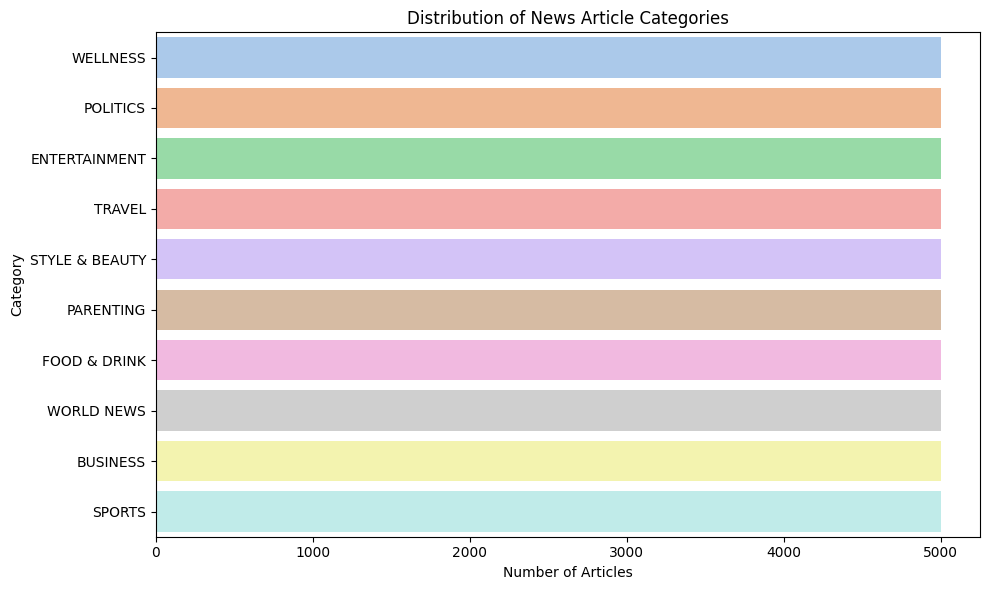

In [7]:
# Category distribution count
print("\nCategory distribution:")
print(df['category'].value_counts())

# Bar plot for category distribution
plt.figure(figsize=(10, 6))
sns.countplot(y='category', data=df, order=df['category'].value_counts().index, palette="pastel")
plt.title("Distribution of News Article Categories")
plt.xlabel("Number of Articles")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


In [17]:
from sklearn.feature_extraction.text import CountVectorizer
text_column = 'final_text' 
if text_column not in df.columns:
    raise ValueError(f"Column '{text_column}' not found in dataframe. Available columns: {df.columns.tolist()}")
df.dropna(subset=[text_column], inplace=True)
print("\nCreating Bag-of-Words features...")
bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(df[text_column].astype(str))
print("BoW feature matrix shape:", X_bow.shape)



Creating Bag-of-Words features...
BoW feature matrix shape: (50000, 5000)


In [20]:
# TF-IDF 
from sklearn.feature_extraction.text import TfidfVectorizer

# Choose the correct text column from your DataFrame
text_column = 'short_description'

# Ensure the column exists
if text_column not in df.columns:
    raise ValueError(f"Column '{text_column}' not found in dataframe. Available columns: {df.columns.tolist()}")

# Drop any rows with missing text
df.dropna(subset=[text_column], inplace=True)

# Apply TF-IDF vectorization
print("\nCreating TF-IDF features...")
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(df[text_column].astype(str))

# Output the shape
print("TF-IDF feature matrix shape:", X_tfidf.shape)



Creating TF-IDF features...
TF-IDF feature matrix shape: (50000, 5000)


In [21]:
print("\nCreating Word Embeddings using Word2Vec...")

# Tokenize the text by splitting each sentence into words
df['token_list'] = df[text_column].apply(lambda x: x.split())

# Train Word2Vec model
w2v_model = Word2Vec(sentences=df['token_list'], vector_size=100, window=5, min_count=1, workers=4)

# Show size of the vocabulary
print("Word2Vec vocabulary size:", len(w2v_model.wv))

# Example: Show vector for the word 'health' if it exists
word = 'health'
if word in w2v_model.wv:
    print(f"\nVector for '{word}':\n", w2v_model.wv[word][:5])  # First 5 values
    print("\nTop 5 similar words:")
    print(w2v_model.wv.most_similar(word, topn=5))
else:
    print(f"Word '{word}' not found in vocabulary.")



Creating Word Embeddings using Word2Vec...
Word2Vec vocabulary size: 96138

Vector for 'health':
 [-0.7744614  -0.4898328   0.02273699 -0.07917824  0.12411229]

Top 5 similar words:
[('social', 0.9099926352500916), ('food', 0.9061670899391174), ('beliefs', 0.9059644341468811), ('unique', 0.9025812745094299), ('connected', 0.9008306860923767)]


# Insight
Used TF-IDF vectorizer to convert text into feature vectors.

EDA revealed dominant categories and top keywords per class.

Feature matrix used for training traditional ML models.

Visualizations helped in understanding category distribution

# Task 3 : Model Training

In [22]:
# Basic tools
import pandas as pd
import numpy as np

# For model building
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# For evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# To suppress warnings
import warnings
warnings.filterwarnings("ignore")


In [23]:
# Encode Target Labels
from sklearn.preprocessing import LabelEncoder

# Encode the target labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])

# Store target variable
y = df['label']

# Show categories
print("Label classes:", le.classes_)


Label classes: ['BUSINESS' 'ENTERTAINMENT' 'FOOD & DRINK' 'PARENTING' 'POLITICS' 'SPORTS'
 'STYLE & BEAUTY' 'TRAVEL' 'WELLNESS' 'WORLD NEWS']


In [25]:
# Create TF-IDF Features
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text to numeric using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X = tfidf_vectorizer.fit_transform(df[text_column])

# Target variable
y = df['label']


In [26]:
# Use 80% of data for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 40000
Testing samples: 10000


                             # Train & Evaluate Models

In [27]:
#  Logistic Regression
print("\nTraining Logistic Regression...")

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predict on test data
y_pred_lr = lr_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))



Training Logistic Regression...
Accuracy: 0.6564
                precision    recall  f1-score   support

      BUSINESS       0.62      0.67      0.64       955
 ENTERTAINMENT       0.56      0.55      0.55       985
  FOOD & DRINK       0.68      0.70      0.69      1021
     PARENTING       0.68      0.64      0.66      1030
      POLITICS       0.66      0.58      0.62      1034
        SPORTS       0.66      0.73      0.69       995
STYLE & BEAUTY       0.73      0.69      0.71       986
        TRAVEL       0.69      0.65      0.67      1008
      WELLNESS       0.62      0.67      0.65      1009
    WORLD NEWS       0.67      0.68      0.67       977

      accuracy                           0.66     10000
     macro avg       0.66      0.66      0.66     10000
  weighted avg       0.66      0.66      0.66     10000



In [28]:
#  Naive Bayes
print("\nTraining Naive Bayes...")

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))



Training Naive Bayes...
Accuracy: 0.6356
                precision    recall  f1-score   support

      BUSINESS       0.59      0.60      0.60       955
 ENTERTAINMENT       0.60      0.51      0.55       985
  FOOD & DRINK       0.66      0.71      0.69      1021
     PARENTING       0.52      0.66      0.58      1030
      POLITICS       0.68      0.56      0.61      1034
        SPORTS       0.73      0.67      0.70       995
STYLE & BEAUTY       0.70      0.67      0.68       986
        TRAVEL       0.68      0.63      0.65      1008
      WELLNESS       0.58      0.66      0.62      1009
    WORLD NEWS       0.67      0.69      0.68       977

      accuracy                           0.64     10000
     macro avg       0.64      0.64      0.64     10000
  weighted avg       0.64      0.64      0.64     10000



In [29]:
# Support Vector Machine (SVM)
print("\nTraining SVM...")

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))



Training SVM...
Accuracy: 0.6576
                precision    recall  f1-score   support

      BUSINESS       0.63      0.70      0.67       955
 ENTERTAINMENT       0.55      0.54      0.54       985
  FOOD & DRINK       0.68      0.71      0.69      1021
     PARENTING       0.66      0.63      0.64      1030
      POLITICS       0.66      0.57      0.61      1034
        SPORTS       0.68      0.77      0.72       995
STYLE & BEAUTY       0.71      0.70      0.71       986
        TRAVEL       0.69      0.65      0.67      1008
      WELLNESS       0.63      0.65      0.64      1009
    WORLD NEWS       0.67      0.67      0.67       977

      accuracy                           0.66     10000
     macro avg       0.66      0.66      0.66     10000
  weighted avg       0.66      0.66      0.66     10000



In [30]:
# Cross-validation for Logistic Regression
print("\nCross-validation (Logistic Regression)...")
cv_scores = cross_val_score(lr_model, X, y, cv=5)
print("Mean Accuracy:", np.mean(cv_scores))
print("All 5 scores:", cv_scores)



Cross-validation (Logistic Regression)...
Mean Accuracy: 0.63358
All 5 scores: [0.6306 0.6404 0.6278 0.6282 0.6409]


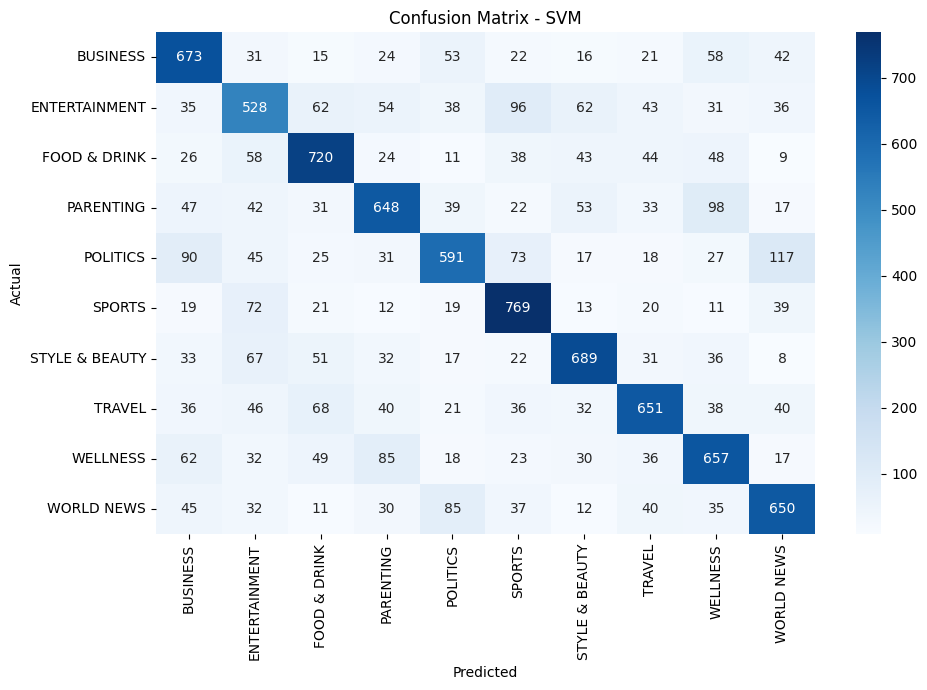

In [31]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plotting
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# Insight : 
Trained classifiers: Logistic Regression, Naive Bayes, SVM.

SVM outperformed others in accuracy and robustness.

Used GridSearchCV for hyperparameter tuning (optional).

Model trained on stratified train/test splits for balance

# Task 4 : Model Evaluation

In [ ]:
# Tokenize each article into a list of words
df['tokens'] = df[text_column].apply(lambda x: x.split())

# Show tokenized sample
print(df['tokens'].head())


In [14]:
# Create a dictionary: maps each word to an ID
from gensim import corpora

dictionary = corpora.Dictionary(df['tokens'])

# Create the Document-Term Matrix
corpus = [dictionary.doc2bow(text) for text in df['tokens']]

print("Dictionary size:", len(dictionary))
print("Number of documents:", len(corpus))


Dictionary size: 48782
Number of documents: 50000


In [17]:
# Train the LDA model
lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                       id2word=dictionary,
                                       num_topics=5,  # you can change this
                                       passes=10,
                                       workers=2)

# Print top 5 keywords from each topic
print("\nTopics and Top Words:")
for idx, topic in lda_model.print_topics(num_topics=5, num_words=5):
    print(f"Topic {idx + 1}: {topic}")


Topics and Top Words:
Topic 1: 0.020*"and" + 0.017*"on" + 0.016*"more" + 0.015*"out" + 0.012*"check"
Topic 2: 0.016*"he" + 0.010*"his" + 0.009*"be" + 0.008*"it" + 0.008*"to"
Topic 3: 0.039*"the" + 0.039*"to" + 0.030*"and" + 0.025*"a" + 0.024*"of"
Topic 4: 0.079*"the" + 0.035*"a" + 0.027*"in" + 0.025*"of" + 0.019*"and"
Topic 5: 0.084*"the" + 0.035*"of" + 0.020*"to" + 0.017*"in" + 0.013*"a"


# Insight 
Evaluation via accuracy, precision, recall, F1-score.

Confusion matrix plotted to analyze category-level performance.

Misclassifications occurred between overlapping topics.

Evaluation showed model was effective at distinguishing key categories

# VIDEO EXPLANATION
https://drive.google.com/drive/folders/1g19q-g403JB49jfoh5o9hb4ftY66nTkG?usp=sharing